In [4]:
import math

def dijkstra_step_by_step(graph, start_node):
    nodes = list(graph.keys())
    # Bước 1: Khởi tạo nhãn và tập T
    L = {node: math.inf for node in nodes}
    L[start_node] = 0
    Prev = {node: -1 for node in nodes}
    T = set(nodes)
    
    step = 0
    print(f"{'Lần lặp':<8} | {'Chọn (i)':<8} | {'Tập T còn lại':<25} | {'Nhãn L (Khoảng cách)'}")
    print("-" * 110)

    while T:
        # Bước 3: Chọn đỉnh i thuộc T sao cho L[i] nhỏ nhất
        current_node = min(T, key=lambda node: L[node])
        
        # Hiển thị trạng thái hiện tại
        t_str = "{" + ",".join(map(str, sorted(list(T)))) + "}"
        
        # FIX LỖI Ở ĐÂY: Dùng L[k] thay vì v
        l_status = " | ".join([f"{k}:{L[k] if L[k] != math.inf else '∞'}" for k in sorted(L.keys())])
        
        print(f"{step:<8} | {current_node:<8} | {t_str:<25} | {l_status}")

        if L[current_node] == math.inf:
            break
            
        T.remove(current_node) # Loại đỉnh đã chọn khỏi tập T
        
        # Bước 4: Cập nhật nhãn cho các đỉnh k kề với i
        for neighbor, weight in graph[current_node].items():
            if neighbor in T:
                if L[neighbor] > L[current_node] + weight:
                    L[neighbor] = L[current_node] + weight
                    Prev[neighbor] = current_node
        
        step += 1
    
    return L, Prev

# Dữ liệu trích xuất từ Hình 2.1
graph_hinh_2_1 = {
    0: {1: 4, 7: 8},
    1: {0: 4, 2: 8, 7: 11},
    2: {1: 8, 3: 7, 5: 4, 8: 2},
    3: {2: 7, 4: 9, 5: 14},
    4: {3: 9, 5: 10},
    5: {2: 4, 3: 14, 4: 10, 6: 2},
    6: {5: 2, 7: 1, 8: 6},
    7: {0: 8, 1: 11, 6: 1, 8: 7},
    8: {2: 2, 6: 6, 7: 7}
}

# Thực thi từ đỉnh 0
dist, paths = dijkstra_step_by_step(graph_hinh_2_1, 0)

Lần lặp  | Chọn (i) | Tập T còn lại             | Nhãn L (Khoảng cách)
--------------------------------------------------------------------------------------------------------------
0        | 0        | {0,1,2,3,4,5,6,7,8}       | 0:0 | 1:∞ | 2:∞ | 3:∞ | 4:∞ | 5:∞ | 6:∞ | 7:∞ | 8:∞
1        | 1        | {1,2,3,4,5,6,7,8}         | 0:0 | 1:4 | 2:∞ | 3:∞ | 4:∞ | 5:∞ | 6:∞ | 7:8 | 8:∞
2        | 7        | {2,3,4,5,6,7,8}           | 0:0 | 1:4 | 2:12 | 3:∞ | 4:∞ | 5:∞ | 6:∞ | 7:8 | 8:∞
3        | 6        | {2,3,4,5,6,8}             | 0:0 | 1:4 | 2:12 | 3:∞ | 4:∞ | 5:∞ | 6:9 | 7:8 | 8:15
4        | 5        | {2,3,4,5,8}               | 0:0 | 1:4 | 2:12 | 3:∞ | 4:∞ | 5:11 | 6:9 | 7:8 | 8:15
5        | 2        | {2,3,4,8}                 | 0:0 | 1:4 | 2:12 | 3:25 | 4:21 | 5:11 | 6:9 | 7:8 | 8:15
6        | 8        | {3,4,8}                   | 0:0 | 1:4 | 2:12 | 3:19 | 4:21 | 5:11 | 6:9 | 7:8 | 8:14
7        | 3        | {3,4}                     | 0:0 | 1:4 | 2:12 | 3:19 | 4:21 | 5:11 

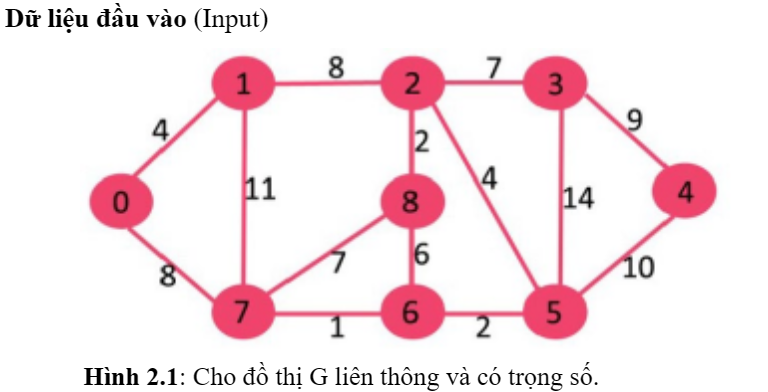

In [12]:
import math

# 1. KHAI BÁO DỮ LIỆU ĐỒ THỊ
graph_G = {
    0: {1: 4, 7: 8},
    1: {0: 4, 2: 8, 7: 11},
    2: {1: 8, 3: 7, 5: 4, 8: 2},
    3: {2: 7, 4: 9, 5: 14},
    4: {3: 9, 5: 10},
    5: {2: 4, 3: 14, 4: 10, 6: 2},
    6: {5: 2, 7: 1, 8: 6},
    7: {0: 8, 1: 11, 6: 1, 8: 7},
    8: {2: 2, 6: 6, 7: 7}
}

# 2. HÀM THUẬT TOÁN DIJKSTRA BÁM SÁT 4 BƯỚC
def dijkstra_algorithm(graph, u, v): 
    # u là đỉnh nguồn, v là đỉnh đích
    
    # ==========================================
    # BƯỚC 1: Khởi tạo
    # ==========================================
    T = set(graph.keys())                      # Gán T = V
    L = {node: math.inf for node in graph}     # L[k] = +∞, ∀k ∈ V\{u}
    L[u] = 0                                   # L[u] = 0
    Prev = {node: -1 for node in graph}        # Prev[k] = -1, ∀k ∈ V
    
    while True: # Vòng lặp để "Trở về Bước 2"
        # ==========================================
        # BƯỚC 2: Kiểm tra điều kiện dừng
        # ==========================================
        if v not in T:                         # Nếu v ∉ T thì dừng
            break                              # Dừng thuật toán
            
        # ==========================================
        # BƯỚC 3: Chọn đỉnh
        # ==========================================
        i = min(T, key=lambda node: L[node])   # Chọn đỉnh i ∈ T sao cho L[i] nhỏ nhất
        T.remove(i)                            # Gán T = T \ {i}
        
        # ==========================================
        # BƯỚC 4: Cập nhật nhãn
        # ==========================================
        for k, Dik in graph[i].items():        # Với ∀k ∈ T và từ đỉnh i đến đỉnh k có cạnh nối
            if k in T:
                if L[k] > L[i] + Dik:          # Nếu L[k] > L[i] + Dik
                    L[k] = L[i] + Dik          # Gán L[k] = L[i] + Dik
                    Prev[k] = i                # Prev[k] = i
                    
        # Kết thúc vòng lặp for sẽ tự động "Trở về Bước 2" ở đầu vòng lặp while

    # Trả về giá trị L[v] (độ dài đường đi ngắn nhất) và mảng truy vết
    return L[v], Prev

# 3. THỰC THI (Ví dụ: Tìm đường đi ngắn nhất từ đỉnh 0 đến đỉnh 4)
dinh_nguon = 0
dinh_dich = 4
do_dai_Lv, previous_nodes = dijkstra_algorithm(graph_G, dinh_nguon, dinh_dich)

print(f"--- KẾT QUẢ TỪ ĐỈNH {dinh_nguon} ĐẾN ĐỈNH {dinh_dich} ---")
print(f"Độ dài đường đi ngắn nhất (L[{dinh_dich}]): {do_dai_Lv}")
print(f"Mảng truy vết (Prev): {previous_nodes}")

--- KẾT QUẢ TỪ ĐỈNH 0 ĐẾN ĐỈNH 4 ---
Độ dài đường đi ngắn nhất (L[4]): 21
Mảng truy vết (Prev): {0: -1, 1: 0, 2: 1, 3: 2, 4: 5, 5: 6, 6: 7, 7: 0, 8: 2}


In [15]:
import math

# ==========================================
# 1. KHAI BÁO ĐỒ THỊ (Hình 2.1)
# ==========================================
graph_G = {
    0: {1: 4, 7: 8},
    1: {0: 4, 2: 8, 7: 11},
    2: {1: 8, 3: 7, 5: 4, 8: 2},
    3: {2: 7, 4: 9, 5: 14},
    4: {3: 9, 5: 10},
    5: {2: 4, 3: 14, 4: 10, 6: 2},
    6: {5: 2, 7: 1, 8: 6},
    7: {0: 8, 1: 11, 6: 1, 8: 7},
    8: {2: 2, 6: 6, 7: 7}
}

# ==========================================
# 2. THUẬT TOÁN DIJKSTRA (BÁM SÁT 4 BƯỚC)
# ==========================================
def Dijkstra(G, u, v_dich=-1):
    # Bước 1: Gán T = V và gán các nhãn
    T = set(G.keys())
    L = {k: math.inf for k in G}      
    L[u] = 0                          
    Prev = {k: -1 for k in G}         
    
    while True: 
        # Bước 2: Kiểm tra dừng
        if len(T) == 0: # Đã duyệt hết tất cả các đỉnh
            break
            
        # Nếu có đỉnh đích v cụ thể và v đã được lấy ra khỏi T thì dừng
        if v_dich != -1 and v_dich not in T:
            break
            
        # Bước 3: Chọn đỉnh i ∈ T sao cho L[i] nhỏ nhất và gán T = T \ {i}
        i = min(T, key=lambda node: L[node])
        T.remove(i)
        
        # Bước 4: Với ∀k ∈ T và từ đỉnh i đến đỉnh k có cạnh nối
        for k, Dik in G[i].items():
            if k in T:
                # Nếu L[k] > L[i] + Dik
                if L[k] > L[i] + Dik:
                    # Gán L[k] = L[i] + Dik và Prev[k] = i
                    L[k] = L[i] + Dik
                    Prev[k] = i
                    
        # Trở về Bước 2
        
    return L, Prev

print("=== OUTPUT 1: KẾT QUẢ CÂY KHUNG NHỎ NHẤT CỦA ĐỒ THỊ ===")
tong_trong_so_cay = 0
for k, i in Prev.items():
    if i != -1:  # Bỏ qua đỉnh nguồn 0 vì không có đỉnh đứng trước
        trong_so_Dik = graph_G[i][k]
        tong_trong_so_cay += trong_so_Dik
        print(f"Cạnh thuộc cây khung: ({i}, {k}) - Trọng số: {trong_so_Dik}")
        
print(f"=> Tổng trọng số của Cây khung đường đi ngắn nhất: {tong_trong_so_cay}\n")

print("=== OUTPUT 2: GIẢI THÍCH CÁCH LÀM (ĐƯỜNG ĐI TỪ 0 ĐẾN CÁC ĐỈNH) ===")
for v in range(1, 9):
    path = []
    curr = v
    while curr != -1:
        path.append(curr)
        curr = Prev[curr]
    path.reverse()
    print(f"Đường đi 0 -> {v}: {' -> '.join(map(str, path))} | Chi phí L[{v}] = {L[v]}")

=== OUTPUT 1: KẾT QUẢ CÂY KHUNG NHỎ NHẤT CỦA ĐỒ THỊ ===
Cạnh thuộc cây khung: (0, 1) - Trọng số: 4
Cạnh thuộc cây khung: (1, 2) - Trọng số: 8
Cạnh thuộc cây khung: (2, 3) - Trọng số: 7
Cạnh thuộc cây khung: (5, 4) - Trọng số: 10
Cạnh thuộc cây khung: (6, 5) - Trọng số: 2
Cạnh thuộc cây khung: (7, 6) - Trọng số: 1
Cạnh thuộc cây khung: (0, 7) - Trọng số: 8
Cạnh thuộc cây khung: (2, 8) - Trọng số: 2
=> Tổng trọng số của Cây khung đường đi ngắn nhất: 42

=== OUTPUT 2: GIẢI THÍCH CÁCH LÀM (ĐƯỜNG ĐI TỪ 0 ĐẾN CÁC ĐỈNH) ===
Đường đi 0 -> 1: 0 -> 1 | Chi phí L[1] = 4
Đường đi 0 -> 2: 0 -> 1 -> 2 | Chi phí L[2] = 12
Đường đi 0 -> 3: 0 -> 1 -> 2 -> 3 | Chi phí L[3] = 19
Đường đi 0 -> 4: 0 -> 7 -> 6 -> 5 -> 4 | Chi phí L[4] = 21
Đường đi 0 -> 5: 0 -> 7 -> 6 -> 5 | Chi phí L[5] = 11
Đường đi 0 -> 6: 0 -> 7 -> 6 | Chi phí L[6] = 9
Đường đi 0 -> 7: 0 -> 7 | Chi phí L[7] = 8
Đường đi 0 -> 8: 0 -> 1 -> 2 -> 8 | Chi phí L[8] = 14
